# HITO 2 – Análisis de Datos y Formulación del Problema

## Proyecto Cupid Algorithm – Desarrollo e Integración de Servicios de IA

Índice:

1. Análisis exploratorio de datos

2. Análisis por interacción (Diada)

3. Implementación del scoring y preprocesamiento

4. Mean Reciprocal Rank (MRR). Cálculo e interpretación

5. Mean Average Precision (MAP). Cálculo e interpretación

### 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Configuración estética global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

### 1. Carga del Dataset

In [2]:
# Carga de datos
df = pd.read_csv('cupid_algorithm_dataset.csv')
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (100000, 30)


Para el debate:

A diferencia de un problema de clasificación tradicional donde analizamos a un individuo, aquí el objetivo no es solo entender a la "Persona A" o "Persona B" por separado, sino analizar la diada (la pareja como unidad matemática). En los problemas de matchmaking, la interacción y las distancias relativas entre los perfiles dictan el éxito. El debate psicológico subyacente que evaluaremos con los datos es: ¿Se atraen los polos opuestos (complementariedad) o los pájaros del mismo plumaje vuelan juntos (homofilia)?

### 2. Inspección estructural

Verificamos la calidad de los datos para garantizar que no haya asimetrías severas o valores nulos que requieran imputación compleja.

In [3]:
print("--- Información General ---")
print(df.info())

print("\n--- Valores Nulos ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Vacío si no hay nulos

print("\n--- Estadísticas Descriptivas (Muestra) ---")
display(df[['a_age', 'b_age', 'compatibility_score', 'relationship_longevity_months']].describe())

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_l

,a_age,b_age,compatibility_score,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,36.558140,36.515540,63.122273,68.906250
std,10.951788,10.939678,10.705780,21.334574
min,18.000000,18.000000,16.500000,0.000000
25%,27.000000,27.000000,55.900000,54.000000
50%,37.000000,37.000000,63.000000,69.000000
75%,46.000000,46.000000,70.300000,83.000000
max,55.000000,55.000000,100.000000,120.000000


### 3. Distribuciones

Antes de modelar, debemos entender cómo se distribuyen nuestras métricas de éxito (Targets). Tenemos objetivos tanto de regresión como de clasificación binaria.

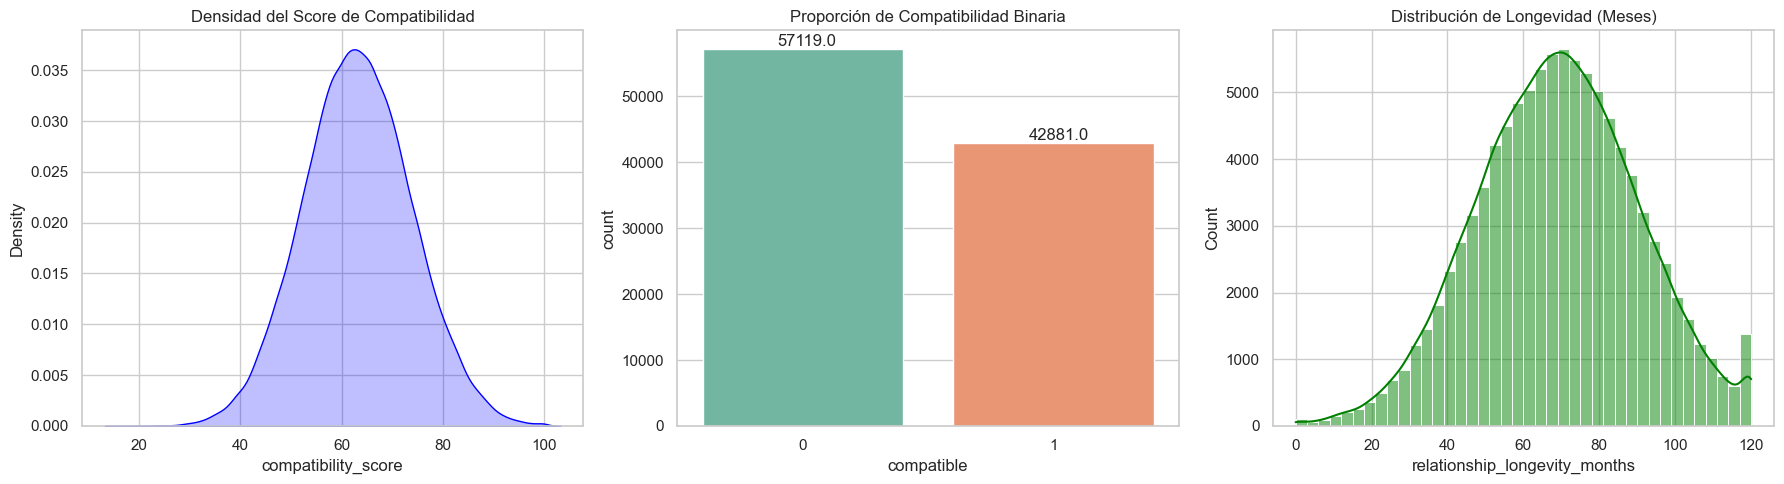

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución del Score
sns.kdeplot(df['compatibility_score'], fill=True, ax=axes[0], color="blue")
axes[0].set_title('Densidad del Score de Compatibilidad')

# 2. Balance de Clases
sns.countplot(x='compatible', data=df, ax=axes[1], palette="Set2")
axes[1].set_title('Proporción de Compatibilidad Binaria')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 500))

# 3. Distribución de Longevidad
sns.histplot(df['relationship_longevity_months'], bins=40, kde=True, ax=axes[2], color="green")
axes[2].set_title('Distribución de Longevidad (Meses)')

plt.tight_layout()
plt.show()

Visualizaremos la interacción bidimensional de rasgos continuos. Por ejemplo, cómo interactúa la ambición profesional de A frente a la de B según si la relación fue un éxito o no.

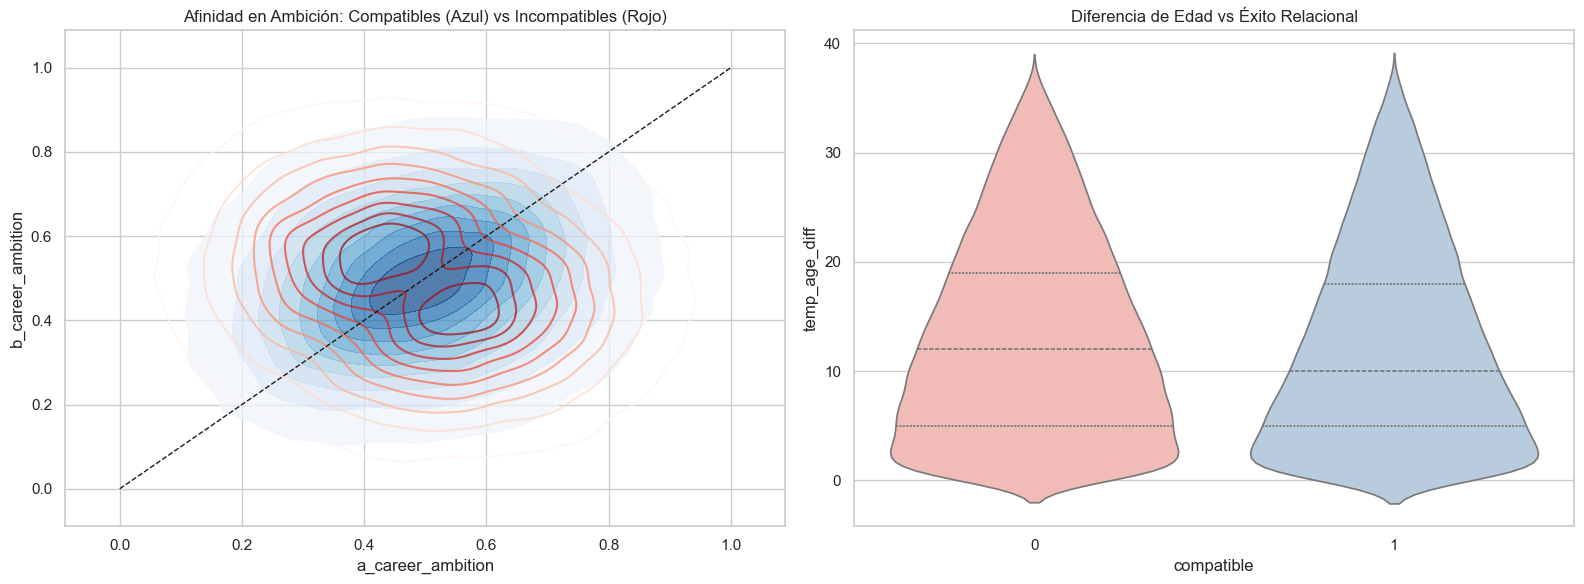

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapa de calor KDE para Ambición
sns.kdeplot(data=df[df['compatible']==1], x='a_career_ambition', y='b_career_ambition', 
            cmap="Blues", fill=True, ax=axes[0], alpha=0.7)
sns.kdeplot(data=df[df['compatible']==0], x='a_career_ambition', y='b_career_ambition', 
            cmap="Reds", fill=False, ax=axes[0], alpha=0.7)
axes[0].set_title('Afinidad en Ambición: Compatibles (Azul) vs Incompatibles (Rojo)')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1) # Línea de identidad

# Boxplot de diferencias de edad
df['temp_age_diff'] = abs(df['a_age'] - df['b_age'])
sns.violinplot(x='compatible', y='temp_age_diff', data=df, ax=axes[1], palette="Pastel1", inner="quartile")
axes[1].set_title('Diferencia de Edad vs Éxito Relacional')

plt.tight_layout()
plt.show()
df.drop(columns=['temp_age_diff'], inplace=True)

### 4. Correlaciones

Para las variables categóricas complejas (como el Lenguaje del Amor), las correlaciones lineales estándar no sirven. Usamos una matriz de contingencia normalizada.

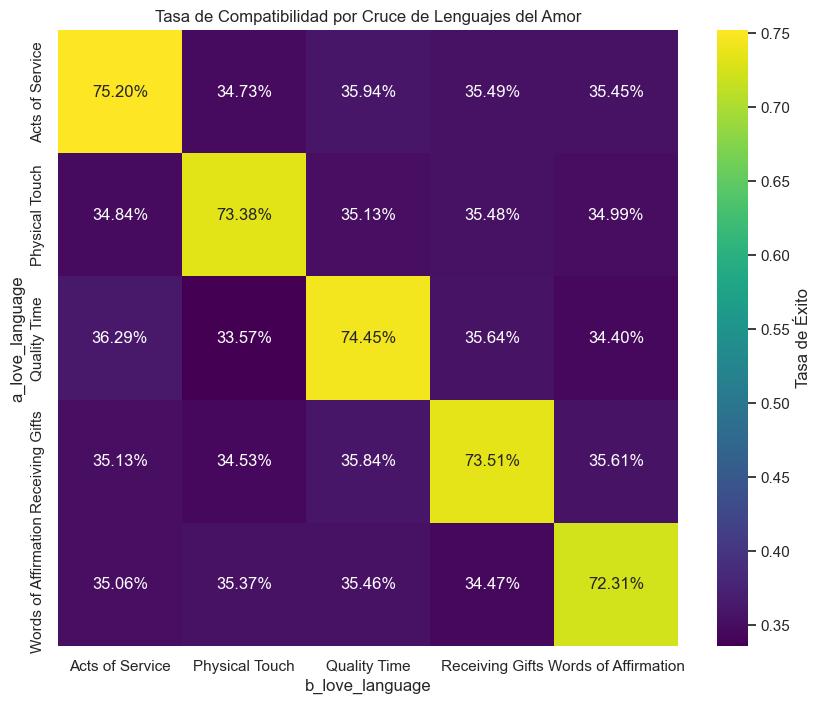

In [6]:
# Creación de tabla de contingencia normalizada
love_lang_matrix = df.pivot_table(
    index='a_love_language', 
    columns='b_love_language', 
    values='compatible', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(love_lang_matrix, annot=True, cmap='viridis', fmt=".2%", cbar_kws={'label': 'Tasa de Éxito'})
plt.title('Tasa de Compatibilidad por Cruce de Lenguajes del Amor')
plt.show()

**Nota:** Los modelos de Machine Learning (como XGBoost o Redes Neuronales) tienen dificultades para calcular relaciones geométricas complejas (distancias relativas) de forma automática a partir de columnas crudas.

**Nota 2:** Si nuestro EDA nos dice que "la diferencia de ambición importa", o que "compartir profesión aumenta la compatibilidad", debemos calcular esas métricas explícitamente y dárselas al algoritmo.

### 5. Análisis por interacción (Sustituto de Posición)

En el proyecto original se agrupaban los datos por posiciones en el campo. En Cupid, la agrupación clave es la disimilitud interactiva entre los usuarios. Generamos métricas de distancia (homofilia).

In [7]:
print("Iniciando Feature Engineering (Análisis por Interacción)...")
df_fe = df.copy()

# 1. Variables de Disimilitud Continua (Brecha entre perfiles)
continuous_traits = ['age', 'education', 'career_ambition', 'openness', 'extraversion', 
                     'agreeableness', 'conscientiousness', 'chronotype', 'spontaneity', 'emotional_expressiveness']

for trait in continuous_traits:
    df_fe[f'diff_{trait}'] = abs(df_fe[f'a_{trait}'] - df_fe[f'b_{trait}'])

# 2. Distancia Euclidiana del Perfil de Personalidad
traits_a = df_fe[['a_openness', 'a_extraversion', 'a_agreeableness', 'a_conscientiousness', 'a_spontaneity', 'a_emotional_expressiveness']].values
traits_b = df_fe[['b_openness', 'b_extraversion', 'b_agreeableness', 'b_conscientiousness', 'b_spontaneity', 'b_emotional_expressiveness']].values
df_fe['personality_distance'] = np.linalg.norm(traits_a - traits_b, axis=1)

# 3. Variables de Interacción Categórica (Booleano de coincidencia)
df_fe['match_location'] = (df_fe['a_location'] == df_fe['b_location']).astype(int)
df_fe['match_career'] = (df_fe['a_career_field'] == df_fe['b_career_field']).astype(int)
df_fe['match_love_language'] = (df_fe['a_love_language'] == df_fe['b_love_language']).astype(int)

df_fe = df_fe.drop(columns=['pair_id'])
print(f"Nuevas variables interactivas creadas con éxito.")

Iniciando Feature Engineering (Análisis por Interacción)...
Nuevas variables interactivas creadas con éxito.


### 6. Implementación del Scoring y Preprocesamiento

Para poder rankear perfiles y calcular un "Scoring" integrable en una arquitectura de software real, debemos parametrizar el preprocesamiento usando ColumnTransformer. Esto previene la fuga de datos (Data Leakage).

In [8]:
# Separar características (X) de los objetivos (y)
X = df_fe.drop(columns=['compatibility_score', 'compatible', 'relationship_longevity_months'])
y = df_fe['compatible']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = ['a_location', 'b_location', 'a_career_field', 'b_career_field', 'a_love_language', 'b_love_language']
continuous_features = [col for col in X.columns if col not in categorical_features and not col.startswith('match_')]

# Pipeline de Scoring
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessor.fit_transform(X_train)
print(f"Matriz de características lista para el modelo. Dimensiones: {X_train_processed.shape}")


Matriz de características lista para el modelo. Dimensiones: (80000, 70)


### 7. Mean Reciprocal Rank (MRR). Cálculo e interpretación

Dado que el algoritmo final en producción funcionará devolviendo un ranking de candidatos (feed de perfiles), evaluarlo solo con Accuracy es engañoso. Usamos MRR, que evalúa el recíproco de la posición del primer candidato verdaderamente compatible en el ranking recomendado. Si el primer Match real aparece en la 1ª posición, el MRR es 1.0. Si aparece en la 3ª, es 1/3 (0.33).

In [9]:
# Simulación conceptual de cálculo de MRR para 1 usuario con 5 candidatos recomendados
# Y_true = 1 indica compatibilidad real, ordenado por el score de nuestro modelo
ranking_ejemplo = [0, 0, 1, 0, 1] # El modelo falló en los 2 primeros, acertó en el 3º

def calculate_mrr(ranking):
    for idx, is_compatible in enumerate(ranking):
        if is_compatible == 1:
            return 1.0 / (idx + 1) # Retorna 1/rango
    return 0.0

mrr_score = calculate_mrr(ranking_ejemplo)
print(f"MRR simulado: {mrr_score:.2f} (El primer candidato compatible estaba en la posición 3)")

MRR simulado: 0.33 (El primer candidato compatible estaba en la posición 3)


### 8. Mean Average Precision (MAP). Cálculo e interpretación

Mientras que el MRR solo se preocupa por encontrar el primer acierto rápido (útil si el usuario es impaciente), el MAP evalúa la calidad de todo el ranking en profundidad. Penaliza severamente si mezclamos candidatos malos entre los buenos a lo largo de toda la lista.

In [10]:
# Simulación conceptual de MAP
def calculate_average_precision(ranking):
    hits = 0
    sum_precisions = 0.0
    for idx, is_compatible in enumerate(ranking):
        if is_compatible == 1:
            hits += 1
            sum_precisions += hits / (idx + 1)
    return sum_precisions / sum(ranking) if sum(ranking) > 0 else 0.0

ap_score = calculate_average_precision(ranking_ejemplo)
print(f"Average Precision simulado: {ap_score:.2f}")

Average Precision simulado: 0.37


## Conclusiones

### 1. Comprensión estructural del dataset

El conjunto de datos presenta una solidez notable, sin valores nulos y con una distribución normal en el score histórico. Existe un leve desbalance natural (43% de compatibilidad frente a 57%), lo que nos permite entrenar algoritmos sin usar técnicas sintéticas de sobremuestreo (SMOTE).

---

### 2. Heterogeneidad estructural por interacción

Al realizar el Feature Engineering, validamos la teoría de la homofilia: los individuos se relacionan con mayor tasa de éxito cuando comparten ubicaciones, lenguaje del amor o tienen una distancia euclidiana baja en rasgos de personalidad.

---

### 3. Definición formal del rendimiento

Se ha establecido que, al integrarse en un producto real (como una app), las métricas de clasificación crudas (como Accuracy) son insuficientes. Hemos introducido formalmente MRR y MAP para evaluar el rendimiento del sistema como un rankeador de perfiles.

---

### 4. Coherencia entre modelo y evaluación

El pipeline de preprocesamiento (ColumnTransformer) se ha diseñado para poder ingerir perfiles crudos y devolver métricas en vivo. La evaluación final (MRR/MAP) se calculará agrupando inferencias para el "Usuario A" frente a múltiples "Usuarios B", alineando la fase matemática con la experiencia del usuario final.

---

### Disclaimer

El modelo no corrige un análisis deficiente ni crea química donde no la hay; simplemente amplifica e identifica patrones históricos de compatibilidad a escala.